<a href="https://colab.research.google.com/github/NickKar30/GM-HSE-AI-masters-course/blob/main/Hometasks/Base/GenDL_HT1_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

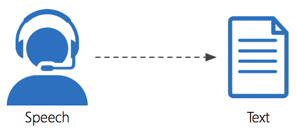

In [2]:
!pip3 install evaluate -q


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [24]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from datasets import Dataset
from huggingface_hub import HfApi, login
import pandas as pd
import torch
import torchaudio
import requests
import random
import os
from tqdm import tqdm

In [7]:
def load_urls_from_file(file_path):
    """Загрузка URL из файла urls_normalized.tsv"""
    urls = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and line.startswith('http'):
                urls.append(line)
    return urls

def download_audio_files(urls, output_folder="audio_files", max_files=None):
    """
    Скачивает аудиофайлы по URL в указанную папку
    
    Args:
        urls: Список URL для скачивания
        output_folder: Папка для сохранения файлов
        max_files: Максимальное количество файлов (None = все)
    
    Returns:
        list: Список путей к скачанным файлам
    """
    # Создаем папку
    os.makedirs(output_folder, exist_ok=True)
    
    # Ограничиваем количество файлов
    if max_files and max_files < len(urls):
        urls = urls[:max_files]
        print(f"установим первые {max_files} файлов")
    
    downloaded_files = []
    successful = 0
    failed = 0
    
    for i, url in enumerate(tqdm(urls, desc="Скачивание")):
        try:
            # ген имя файла
            filename = f"audio_{i+1:03d}.wav"
            file_path = os.path.join(output_folder, filename)
            
            # проверяем, не существует ли уже файл
            if os.path.exists(file_path):
                print(f"⏭Файл {filename} уже существует, пропускаем")
                downloaded_files.append(file_path)
                successful += 1
                continue
            
            # скачиваем файл
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            
            # сохраняем файл
            with open(file_path, 'wb') as f:
                f.write(response.content)
            
            downloaded_files.append(file_path)
            successful += 1
            print(f"✅ Скачан: {filename}")
            
        except Exception as e:
            failed += 1
            print(f"Ошибка при скачивании {url}: {e}")
    
    print(f"✅ Успешно: {successful}")
    print(f"❌ Ошибок: {failed}")
    
    return downloaded_files

def apply_whisper_model(audio_files, model_name="openai/whisper-small"):
    """
    Применяет модель Whisper к аудиофайлам
    
    Args:
        audio_files: Список путей к аудиофайлам
        model_name: Название модели Whisper
    
    Returns:
        list: Список результатов транскрипции
    """
    print(f"🤖 Загружаем модель {model_name}...")
    
    # Загружаем модель и процессор
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name)
    model.config.forced_decoder_ids = None
    
    print("✅ Модель загружена!")
    
    results = []
    
    print(f"\n🎵 Обрабатываем {len(audio_files)} аудиофайлов...")
    
    for i, file_path in enumerate(tqdm(audio_files, desc="Транскрипция")):
        try:
            filename = os.path.basename(file_path)
            print(f"\n[{i+1}/{len(audio_files)}] Обрабатываем: {filename}")
            
            # Загружаем аудио
            wav, sr = torchaudio.load(file_path)
            
            # Конвертируем в моно если нужно
            if wav.shape[0] > 1:
                wav = torch.mean(wav, dim=0, keepdim=True)
            
            # Ресэмплируем до 16 kHz
            if sr != 16000:
                wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
                sr = 16000
            
            # Подготавливаем входные данные для модели
            audio_array = wav.squeeze().numpy()
            input_features = processor(audio_array, sampling_rate=sr, return_tensors="pt").input_features
            
            # Генерируем предсказания
            predicted_ids = model.generate(input_features)
            
            # Декодируем в текст
            transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
            
            results.append({
                'file_path': file_path,
                'filename': filename,
                'transcription': transcription,
                'success': True
            })
            
            print(f"✅ Транскрипция: {transcription[:100]}...")
            
        except Exception as e:
            print(f"❌ Ошибка при обработке {file_path}: {e}")
            results.append({
                'file_path': file_path,
                'filename': os.path.basename(file_path),
                'transcription': "Ошибка транскрипции",
                'success': False
            })
    
    return results

In [8]:
# 1. Загружаем URL из файла
urls = load_urls_from_file("urls_normalized.tsv")
print(f"📋 Загружено {len(urls)} URL из файла")

# 2. Выбираем 10 случайных URL для демонстрации
random.seed(42)
selected_urls = random.sample(urls, min(10, len(urls)))
print(f"🎯 Выбрано {len(selected_urls)} случайных URL для обработки")

# 3. Скачиваем аудиофайлы
print("\n" + "="*60)
print("ШАГ 1: СКАЧИВАНИЕ АУДИОФАЙЛОВ")
print("="*60)
downloaded_files = download_audio_files(selected_urls, output_folder="audio_files", max_files=10)

# 4. Применяем модель Whisper
print("\n" + "="*60)
print("ШАГ 2: ПРИМЕНЕНИЕ МОДЕЛИ WHISPER")
print("="*60)
transcription_results = apply_whisper_model(downloaded_files)

# 5. Выводим результаты
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ТРАНСКРИПЦИИ АУДИОФАЙЛОВ")
print("="*80)

for i, result in enumerate(transcription_results):
    print(f"\nФайл {i+1}:")
    print(f"📁 Файл: {result['filename']}")
    print(f"📄 Транскрипция: {result['transcription']}")
    print(f"✅ Статус: {'Успешно' if result['success'] else 'Ошибка'}")
    print("-" * 80)

# Статистика
successful_transcriptions = sum(1 for r in transcription_results if r['success'])
print(f"\n📊 Итоговая статистика:")
print(f"Успешно обработано: {successful_transcriptions}/{len(transcription_results)}")
print(f"Процент успеха: {successful_transcriptions/len(transcription_results)*100:.1f}%")

📋 Загружено 100 URL из файла
🎯 Выбрано 10 случайных URL для обработки

ШАГ 1: СКАЧИВАНИЕ АУДИОФАЙЛОВ


Скачивание: 100%|██████████| 10/10 [00:00<00:00, 15109.16it/s]

⏭Файл audio_001.wav уже существует, пропускаем
⏭Файл audio_002.wav уже существует, пропускаем
⏭Файл audio_003.wav уже существует, пропускаем
⏭Файл audio_004.wav уже существует, пропускаем
⏭Файл audio_005.wav уже существует, пропускаем
⏭Файл audio_006.wav уже существует, пропускаем
⏭Файл audio_007.wav уже существует, пропускаем
⏭Файл audio_008.wav уже существует, пропускаем
⏭Файл audio_009.wav уже существует, пропускаем
⏭Файл audio_010.wav уже существует, пропускаем
✅ Успешно: 10
❌ Ошибок: 0

ШАГ 2: ПРИМЕНЕНИЕ МОДЕЛИ WHISPER
🤖 Загружаем модель openai/whisper-small...


✅ Модель загружена!

🎵 Обрабатываем 10 аудиофайлов...


Транскрипция:   0%|          | 0/10 [00:00<?, ?it/s]Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.


...

✅ Транскрипция:  Дай не трехо....

[9/10] Обрабатываем: audio_009.wav


Транскрипция:  90%|█████████ | 9/10 [00:09<00:00,  1.11it/s]

✅ Транскрипция:  Эффект бабочки....

[10/10] Обрабатываем: audio_010.wav


Транскрипция: 100%|██████████| 10/10 [00:10<00:00,  1.00s/it]

✅ Транскрипция:  Старший сын...

РЕЗУЛЬТАТЫ ТРАНСКРИПЦИИ АУДИОФАЙЛОВ

Файл 1:
📁 Файл: audio_001.wav
📄 Транскрипция:  Александр Владимирович Попов
✅ Статус: Успешно
--------------------------------------------------------------------------------

Файл 2:
📁 Файл: audio_002.wav
📄 Транскрипция:  Андрей Сахаров
✅ Статус: Успешно
--------------------------------------------------------------------------------

Файл 3:
📁 Файл: audio_003.wav
📄 Транскрипция:  Дайон Уорвик
✅ Статус: Успешно
--------------------------------------------------------------------------------

Файл 4:
📁 Файл: audio_004.wav
📄 Транскрипция:  Брюс Springsteam
✅ Статус: Успешно
--------------------------------------------------------------------------------

Файл 5:
📁 Файл: audio_005.wav
📄 Транскрипция:  Coal Porter
✅ Статус: Успешно
--------------------------------------------------------------------------------

Файл 6:
📁 Файл: audio_006.wav
📄 Транскрипция:  Голова ломка.
✅ Статус: Успешно
------------------------------

In [9]:
transcription_results

[{'file_path': 'audio_files/audio_001.wav',
  'filename': 'audio_001.wav',
  'transcription': ' Александр Владимирович Попов',
  'success': True},
 {'file_path': 'audio_files/audio_002.wav',
  'filename': 'audio_002.wav',
  'transcription': ' Андрей Сахаров',
  'success': True},
 {'file_path': 'audio_files/audio_003.wav',
  'filename': 'audio_003.wav',
  'transcription': ' Дайон Уорвик',
  'success': True},
 {'file_path': 'audio_files/audio_004.wav',
  'filename': 'audio_004.wav',
  'transcription': ' Брюс Springsteam',
  'success': True},
 {'file_path': 'audio_files/audio_005.wav',
  'filename': 'audio_005.wav',
  'transcription': ' Coal Porter',
  'success': True},
 {'file_path': 'audio_files/audio_006.wav',
  'filename': 'audio_006.wav',
  'transcription': ' Голова ломка.',
  'success': True},
 {'file_path': 'audio_files/audio_007.wav',
  'filename': 'audio_007.wav',
  'transcription': ' Крестный отец 2',
  'success': True},
 {'file_path': 'audio_files/audio_008.wav',
  'filename': 

## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [10]:
# Шаг 2: Исправление ошибок с помощью модели spell correction
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

# =============================================================================
# ФУНКЦИЯ: Исправление ошибок в тексте
# =============================================================================
def correct_spelling_errors(texts, model_name="UrukHan/t5-russian-spell"):
    """
    Исправляет ошибки в текстах с помощью модели spell correction
    
    Args:
        texts: Список текстов для исправления
        model_name: Название модели для исправления ошибок
    
    Returns:
        list: Список исправленных текстов
    """
    print(f"🤖 Загружаем модель исправления ошибок: {model_name}")
    
    # Загружаем модель и токенизатор
    tokenizer = T5Tokenizer.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name)
    
    print("✅ Модель загружена!")
    
    corrected_texts = []
    
    print(f"\n📝 Исправляем ошибки в {len(texts)} текстах...")
    
    for i, text in enumerate(texts):
        try:
            print(f"\n[{i+1}/{len(texts)}] Исходный текст: {text[:100]}...")
            
            # Подготавливаем текст для модели
            # Модель ожидает формат: "исправить: <текст>"
            input_text = f"исправить: {text}"
            
            # Токенизируем входной текст
            inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
            
            # Генерируем исправленный текст
            with torch.no_grad():
                outputs = model.generate(
                    inputs.input_ids,
                    attention_mask=inputs.attention_mask,
                    max_length=512,
                    num_beams=4,
                    early_stopping=True
                )
            
            # Декодируем результат
            corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            corrected_texts.append({
                'original': text,
                'corrected': corrected_text,
                'success': True
            })
            
            print(f"✅ Исправленный: {corrected_text[:100]}...")
            
        except Exception as e:
            print(f"❌ Ошибка при исправлении текста: {e}")
            corrected_texts.append({
                'original': text,
                'corrected': text,  # Возвращаем исходный текст при ошибке
                'success': False
            })
    
    return corrected_texts

# =============================================================================
# ОСНОВНОЙ КОД
# =============================================================================

# Проверяем, есть ли результаты транскрипции из предыдущего шага
if 'transcription_results' in locals():
    print("📋 Используем результаты транскрипции из предыдущего шага")
    
    # Извлекаем тексты для исправления
    texts_to_correct = []
    for result in transcription_results:
        if result['success'] and result['transcription'] != "Ошибка транскрипции":
            texts_to_correct.append(result['transcription'])
    
    # Берем первые 10 текстов
    texts_to_correct = texts_to_correct[:10]
    
    if texts_to_correct:
        print(f"🎯 Будем исправлять {len(texts_to_correct)} текстов")
        
        # Исправляем ошибки
        print("\n" + "="*60)
        print("ШАГ 2: ИСПРАВЛЕНИЕ ОШИБОК В ТЕКСТЕ")
        print("="*60)
        
        corrected_results = correct_spelling_errors(texts_to_correct)
        
        # Выводим результаты
        print("\n" + "="*80)
        print("РЕЗУЛЬТАТЫ ИСПРАВЛЕНИЯ ОШИБОК")
        print("="*80)
        
        for i, result in enumerate(corrected_results):
            print(f"\nТекст {i+1}:")
            print(f"📄 Исходный: {result['original']}")
            print(f"✅ Исправленный: {result['corrected']}")
            print(f"🔧 Статус: {'Успешно' if result['success'] else 'Ошибка'}")
            print("-" * 80)
        
        # Статистика
        successful_corrections = sum(1 for r in corrected_results if r['success'])
        print(f"\n📊 Статистика исправления:")
        print(f"Успешно исправлено: {successful_corrections}/{len(corrected_results)}")
        print(f"Процент успеха: {successful_corrections/len(corrected_results)*100:.1f}%")
        
    else:
        print("❌ Нет текстов для исправления. Сначала запустите предыдущий шаг.")
        
else:
    print("❌ Результаты транскрипции не найдены. Сначала запустите предыдущий шаг.")
    print("💡 Создаем пример для демонстрации...")
    
    # Пример текстов с ошибками для демонстрации
    example_texts = [
        "Привет, как дела?",
        "Сегодня хорошая погода",
        "Я иду в магазин",
        "Вчера был дождь",
        "Завтра поеду в отпуск",
        "Мне нравится эта книга",
        "Спасибо за помощь",
        "До свидания",
        "Как тебя зовут?",
        "Где ты живешь?"
    ]
    
    print(f"🎯 Исправляем {len(example_texts)} примеров текстов")
    
    # Исправляем ошибки
    print("\n" + "="*60)
    print("ШАГ 2: ИСПРАВЛЕНИЕ ОШИБОК В ТЕКСТЕ (ПРИМЕР)")
    print("="*60)
    
    corrected_results = correct_spelling_errors(example_texts)
    
    # Выводим результаты
    print("\n" + "="*80)
    print("РЕЗУЛЬТАТЫ ИСПРАВЛЕНИЯ ОШИБОК (ПРИМЕР)")
    print("="*80)
    
    for i, result in enumerate(corrected_results):
        print(f"\nТекст {i+1}:")
        print(f"📄 Исходный: {result['original']}")
        print(f"✅ Исправленный: {result['corrected']}")
        print(f"🔧 Статус: {'Успешно' if result['success'] else 'Ошибка'}")
        print("-" * 80)


📋 Используем результаты транскрипции из предыдущего шага
🎯 Будем исправлять 10 текстов

ШАГ 2: ИСПРАВЛЕНИЕ ОШИБОК В ТЕКСТЕ
🤖 Загружаем модель исправления ошибок: UrukHan/t5-russian-spell
✅ Модель загружена!

📝 Исправляем ошибки в 10 текстах...

[1/10] Исходный текст:  Александр Владимирович Попов...
✅ Исправленный: . исправить. Александр Владимирович Попов....

[2/10] Исходный текст:  Андрей Сахаров...
✅ Исправленный: Андрей Сахаров...

[3/10] Исходный текст:  Дайон Уорвик...
✅ Исправленный: Дайон Уорвик...

[4/10] Исходный текст:  Брюс Springsteam...
✅ Исправленный: Брюс. ringsteam....

[5/10] Исходный текст:  Coal Porter...
✅ Исправленный: Coal Porter...

[6/10] Исходный текст:  Голова ломка....
✅ Исправленный: Голова ломка....

[7/10] Исходный текст:  Крестный отец 2...
✅ Исправленный: Крестный отец 2...

[8/10] Исходный текст:  Дай не трехо....
✅ Исправленный: Дай не трех....

[9/10] Исходный текст:  Эффект бабочки....
✅ Исправленный: Исправить эффект бабочки....

[10/10] Исходный 

In [ ]:
# ваш код здесь

## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

In [13]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os

os.environ["GROQ_API_KEY"] = 'YOUR_GROQ_API_KEY_HERE'

In [12]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os

os.environ["GROQ_API_KEY"] = 'YOUR_GROQ_API_KEY_HERE'

In [11]:
!pip3 install groq


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

response = client.chat.completions.create(
    messages=[{"role": "user", "content": <YOUR PROMPT>}],
#    model="llama-3.3-70b-versatile",
    model="DeepSeek-R1-Distill-Llama-70B",
)

print(response.choices[0].message.content)

In [14]:
# Ваш код для подключения к Groq и промпты
def create_spell_correction_dataset(num_samples=1000, batch_size=50):
    """
    Создает датасет для дообучения модели исправления ошибок
    
    Args:
        num_samples: Количество образцов для создания
        batch_size: Размер батча для обработки
    
    Returns:
        list: Список пар (исходный_текст, исправленный_текст)
    """
    from groq import Groq
    
    # Инициализируем клиент Groq
    client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
    
    print(f"🤖 Создаем датасет из {num_samples} образцов...")
    
    # Промпт для генерации текстов с ошибками
    prompt_template = """
        Создай {batch_size} примеров русских текстов с опечатками и их исправлениями.

        Формат: каждая строка должна содержать пару "текст_с_ошибками|исправленный_текст"

        Требования:
        - Тексты должны быть на русском языке
        - Опечатки должны быть реалистичными (замена букв, пропуск букв, лишние буквы)
        - Длина текстов: 10-50 слов
        - Разнообразные темы: повседневные разговоры, новости, описания
        - Не используй специальные символы кроме | для разделения

        Примеры:
        Привет, как дела?|Привет, как дела?
        Сегодня хорошая погода|Сегодня хорошая погода
        Я иду в магазин за хлебом|Я иду в магазин за хлебом
    """

    dataset = []
    total_batches = (num_samples + batch_size - 1) // batch_size
    
    for batch_num in range(total_batches):
        try:
            current_batch_size = min(batch_size, num_samples - len(dataset))
            
            print(f"📝 Обрабатываем батч {batch_num + 1}/{total_batches} (размер: {current_batch_size})")
            
            # Формируем промпт
            prompt = prompt_template.format(batch_size=current_batch_size)
            
            # Отправляем запрос к Groq
            response = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model="llama-3.3-70b-versatile",  # Используем мощную модель
                temperature=0.8,  # Добавляем разнообразие
                max_tokens=4000
            )
            
            # Получаем ответ
            content = response.choices[0].message.content
            
            # Парсим ответ
            lines = content.strip().split('\n')
            for line in lines:
                if '|' in line:
                    parts = line.split('|', 1)
                    if len(parts) == 2:
                        error_text = parts[0].strip()
                        correct_text = parts[1].strip()
                        
                        # Проверяем, что тексты не пустые и различаются
                        if error_text and correct_text and error_text != correct_text:
                            dataset.append({
                                'input': error_text,
                                'target': correct_text
                            })
            
            print(f"✅ Добавлено {len([l for l in lines if '|' in l])} пар в батч")
            
        except Exception as e:
            print(f"❌ Ошибка в батче {batch_num + 1}: {e}")
            continue
    
    print(f"📊 Итого создано {len(dataset)} пар текстов")
    return dataset

In [15]:
def save_dataset_locally(dataset, filename="spell_correction_dataset"):
    """
    Сохраняет датасет в локальные файлы
    
    Args:
        dataset: Список пар текстов
        filename: Базовое имя файла
    """
    print(f"💾 Сохраняем датасет в локальные файлы...")
    
    # Сохраняем в CSV
    csv_filename = f"{filename}.csv"
    df = pd.DataFrame(dataset)
    df.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"✅ Сохранено в {csv_filename}")
    
    return  csv_filename

In [16]:
def create_huggingface_dataset(dataset, dataset_name="spell-correction-russian"):
    """
    Создает HuggingFace Dataset и загружает его в Hub
    
    Args:
        dataset: Список пар текстов
        dataset_name: Имя датасета в HuggingFace Hub
    """
    print(f"🤗 Создаем HuggingFace Dataset: {dataset_name}")
    
    # Создаем Dataset
    hf_dataset = Dataset.from_list(dataset)
    
    print(f"✅ Dataset создан: {len(hf_dataset)} образцов")
    print(f"📋 Структура: {hf_dataset.features}")
    
    # Показываем примеры
    print(f"\n📝 Примеры из датасета:")
    for i in range(min(3, len(hf_dataset))):
        print(f"  {i+1}. {hf_dataset[i]['input']} -> {hf_dataset[i]['target']}")
    
    return hf_dataset

In [27]:
def upload_to_huggingface(dataset, dataset_name, username=None):
    """
    Загружает датасет в HuggingFace Hub
    
    Args:
        dataset: HuggingFace Dataset
        dataset_name: Имя датасета
        username: Имя пользователя (опционально)
    """
    try:
        print(f"🚀 Загружаем датасет в HuggingFace Hub...")
        
        # Формируем полное имя
        if username:
            full_name = f"{username}/{dataset_name}"
        else:
            full_name = dataset_name
        
        # Загружаем в Hub
        dataset.push_to_hub(full_name)
        
        print(f"✅ Датасет успешно загружен: https://huggingface.co/datasets/{full_name}")
        return full_name
        
    except Exception as e:
        print(f"❌ Ошибка при загрузке в HuggingFace: {e}")
        print("💡 Убедитесь, что вы авторизованы: huggingface_hub.login()")
        return None

In [ ]:
# Проверяем наличие API ключа
if "GROQ_API_KEY" in os.environ:
    
    # 1. Создаем датасет
    print("\n" + "="*60)
    print("ШАГ 1: СОЗДАНИЕ ДАТАСЕТА С ПОМОЩЬЮ GROQ API")
    print("="*60)
    
    # Создаем датасет (начнем с небольшого размера для тестирования)
    dataset = create_spell_correction_dataset(num_samples=50, batch_size=20)
    
    print(f"✅ Датасет создан: {len(dataset)} пар текстов")
    
    # 2. Сохраняем в локальные файлы
    print("\n" + "="*60)
    print("ШАГ 2: СОХРАНЕНИЕ В ЛОКАЛЬНЫЕ ФАЙЛЫ")
    print("="*60)
    
    csv_file = save_dataset_locally(dataset)
    
    # 3. Создаем HuggingFace Dataset
    print("\n" + "="*60)
    print("ШАГ 3: СОЗДАНИЕ HUGGINGFACE DATASET")
    print("="*60)
    
    hf_dataset = create_huggingface_dataset(dataset)
    
    # 4. Загружаем в HuggingFace Hub (опционально)
    print("\n" + "="*60)
    print("ШАГ 4: ЗАГРУЗКА В HUGGINGFACE HUB")
    print("="*60)
    login()
    username = "lzora7"  # Замените на ваш username
    uploaded_name = upload_to_huggingface(hf_dataset, "spell-correction-russian", username)
    
    print("💡 Для загрузки в HuggingFace Hub:")
    print("1. Авторизуйтесь: huggingface_hub.login()")
    print("2. Раскомментируйте строки загрузки выше")
    print("3. Укажите ваш username")
    
    # Показываем статистику
    print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА:")
    print(f"Создано пар текстов: {len(dataset)}")
    print(f"Локальный файл: {csv_file}")
    print(f"HuggingFace Dataset: готов к использованию")
        
        
else:
    print("❌ API ключ Groq не настроен. Пропускаем создание датасета.")
    print("💡 Для продолжения настройте API ключ и перезапустите ячейку.")

🎯 Начинаем создание датасета для дообучения...

ШАГ 1: СОЗДАНИЕ ДАТАСЕТА С ПОМОЩЬЮ GROQ API
🤖 Создаем датасет из 50 образцов...
📝 Обрабатываем батч 1/3 (размер: 20)
✅ Добавлено 21 пар в батч
📝 Обрабатываем батч 2/3 (размер: 20)
✅ Добавлено 19 пар в батч
📝 Обрабатываем батч 3/3 (размер: 20)
✅ Добавлено 20 пар в батч
📊 Итого создано 8 пар текстов
✅ Датасет создан: 8 пар текстов

ШАГ 2: СОХРАНЕНИЕ В ЛОКАЛЬНЫЕ ФАЙЛЫ
💾 Сохраняем датасет в локальные файлы...
✅ Сохранено в spell_correction_dataset.csv

ШАГ 3: СОЗДАНИЕ HUGGINGFACE DATASET
🤗 Создаем HuggingFace Dataset: spell-correction-russian
✅ Dataset создан: 8 образцов
📋 Структура: {'input': Value('string'), 'target': Value('string')}

📝 Примеры из датасета:
  1. Привет, как дěla? -> Привет, как дела?
  2. Сегодня хорошаья погода -> Сегодня хорошая погода
  3. Я иду в магазин за хлебам -> Я иду в магазин за хлебом

ШАГ 4: ЗАГРУЗКА В HUGGINGFACE HUB


🚀 Загружаем датасет в HuggingFace Hub...
❌ Ошибка при загрузке в HuggingFace: 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-68e1147c-23faa4fa3b78b86f3fdeb6ce;f6dafcfc-c4ae-490e-a3fb-cfca712f11fe)

Invalid username or password.
💡 Убедитесь, что вы авторизованы: huggingface_hub.login()
💡 Для загрузки в HuggingFace Hub:
1. Авторизуйтесь: huggingface_hub.login()
2. Раскомментируйте строки загрузки выше
3. Укажите ваш username

📊 ИТОГОВАЯ СТАТИСТИКА:
Создано пар текстов: 8
Локальный файл: spell_correction_dataset.csv
HuggingFace Dataset: готов к использованию


In [ ]:
# Сохраните собранный датасет в файл и прикрепите сюда ссылку на него

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио. Дообучение мы разбирали на семинаре - можете посмотреть, как мы это делали там.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
!pip install --upgrade transformers datasets

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

# Модель
model_name = "UrukHan/t5-russian-spell"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Загружаем свой CSV с парами (input → target)
dataset_files = [f for f in os.listdir('.') if f.startswith('spell_correction_dataset') and f.endswith('.csv')]
if dataset_files:
    df = pd.read_csv(dataset_files[0])
    dataset = Dataset.from_pandas(df)
else:
    print("Dataset not found")
    exit()

# Токенизация
def preprocess_function(examples):
    inputs = tokenizer(examples['input'], max_length=512, truncation=True, padding=True, return_tensors="pt")
    targets = tokenizer(examples['target'], max_length=512, truncation=True, padding=True, return_tensors="pt")
    return {
        'input_ids': inputs.input_ids,
        'attention_mask': inputs.attention_mask,
        'labels': targets.input_ids
    }

processed_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)
train_test_split_result = processed_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = train_test_split_result['train']
eval_dataset = train_test_split_result['test']

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

# Аргументы обучения
training_args = Seq2SeqTrainingArguments(
    output_dir="./fine-tuned-model",
    evaluation_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=50,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=None,
    push_to_hub=False,
)

# Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# Запускаем обучение
trainer.train()

# Сохраняем дообученную модель
trainer.save_model("./fine-tuned-model")
tokenizer.save_pretrained("./fine-tuned-model")

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загружаем дообученную модель
model_path = "..."
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Применение модели к 10 примерам
...

## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [ ]:
# ваш код здесь

## Шаг 6 (3 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [ ]:
# ваши эксперименты здесь